# Exploratory data analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv("/content/cleaned_heart_disease_group_task.csv")
df.head()

,age,sex,resting_bp,cholesterol,fasting_bs,max_heart_rate,exercise_angina,oldpeak,num_major_vessels,chest_pain_type_0,...,resting_ecg_0,resting_ecg_1,resting_ecg_2,slope_1,slope_2,slope_3,thal_fixed,thal_normal,thal_reversible,heart_disease
0,63,1,145,233,1,150,0,2.3,0,0,...,0,0,1,0,0,1,1,0,0,0
1,67,1,160,286,0,108,1,1.5,3,0,...,0,0,1,0,1,0,0,1,0,1
2,67,1,120,229,0,129,1,2.6,2,0,...,0,0,1,0,1,0,0,0,1,0
3,37,1,130,250,0,187,0,3.5,0,0,...,1,0,0,0,0,1,0,1,0,0
4,41,0,130,204,0,172,0,1.4,0,0,...,0,0,1,1,0,0,0,1,0,0


In [ ]:
df.shape

(301, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                301 non-null    int64  
 1   sex                301 non-null    int64  
 2   resting_bp         301 non-null    int64  
 3   cholesterol        301 non-null    int64  
 4   fasting_bs         301 non-null    int64  
 5   max_heart_rate     301 non-null    int64  
 6   exercise_angina    301 non-null    int64  
 7   oldpeak            301 non-null    float64
 8   num_major_vessels  301 non-null    int64  
 9   chest_pain_type_0  301 non-null    int64  
 10  chest_pain_type_1  301 non-null    int64  
 11  chest_pain_type_2  301 non-null    int64  
 12  chest_pain_type_3  301 non-null    int64  
 13  chest_pain_type_4  301 non-null    int64  
 14  resting_ecg_0      301 non-null    int64  
 15  resting_ecg_1      301 non-null    int64  
 16  resting_ecg_2      301 non

In [ ]:
df.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_heart_rate,exercise_angina,oldpeak,num_major_vessels,chest_pain_type_0,...,resting_ecg_0,resting_ecg_1,resting_ecg_2,slope_1,slope_2,slope_3,thal_fixed,thal_normal,thal_reversible,heart_disease
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,...,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.00000,301.000000
mean,54.571429,0.677741,131.684385,246.817276,0.146179,149.308970,0.328904,1.061462,0.677741,0.009967,...,0.488372,0.026578,0.485050,0.475083,0.455150,0.069767,0.059801,0.558140,0.38206,0.275748
std,9.041702,0.468120,17.709415,52.186619,0.353874,22.953015,0.470597,1.167295,0.937623,0.099500,...,0.500697,0.161115,0.500609,0.500210,0.498814,0.255179,0.237512,0.497435,0.48670,0.447634
min,29.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,132.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,56.000000,1.000000,130.000000,242.000000,0.000000,152.000000,0.000000,0.800000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000
75%,61.000000,1.000000,140.000000,275.000000,0.000000,165.000000,1.000000,1.600000,1.000000,0.000000,...,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.00000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,202.000000,1.000000,6.200000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [ ]:
print(f'Missing values: {df.isna().sum().sum()}')

Missing values: 0


In [ ]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [ ]:
print(f'Class counts:\n', df['heart_disease'].value_counts())

Class counts:
 heart_disease
0    218
1     83
Name: count, dtype: int64




---



# Visual EDA, train/test split, and scaling

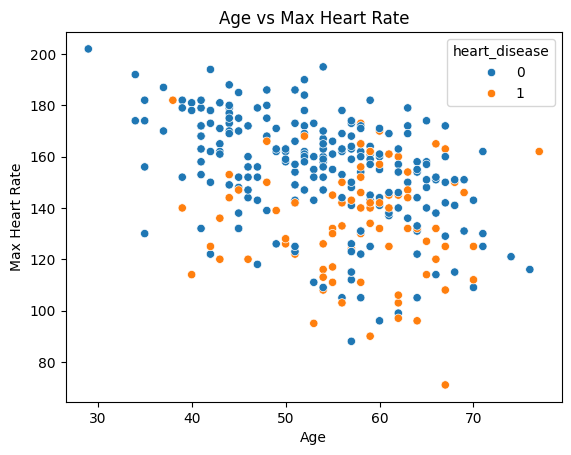

In [ ]:
sns.scatterplot(data=df, x="age", y="max_heart_rate", hue = "heart_disease")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Age vs Max Heart Rate")
plt.show()

In [ ]:
X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



---



# Baseline model and Logistic Regression evaluation

Dummy

In [ ]:
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_scaled, y_train)
y_pred_dummy = dummy_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_dummy))

              precision    recall  f1-score   support

           0       0.72      1.00      0.84        44
           1       0.00      0.00      0.00        17

    accuracy                           0.72        61
   macro avg       0.36      0.50      0.42        61
weighted avg       0.52      0.72      0.60        61



In [ ]:
dummy_acc = accuracy_score(y_test, y_pred_dummy)
print(f'Accuracy: {dummy_acc: .4f}')

dummy_recall = recall_score(y_test, y_pred_dummy)
print(f'Recall: {dummy_recall: .4f}')

dummy_fscore = f1_score(y_test, y_pred_dummy)
print(f'F1 score: {dummy_fscore}')

Accuracy:  0.7213
Recall:  0.0000
F1 score: 0.0


Logistic regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr: .4f}')
print(classification_report(y_test, y_pred_lr))

lr_recall = recall_score(y_test, y_pred_lr)
lr_fscore = f1_score(y_test, y_pred_lr)

Accuracy:  0.8361
              precision    recall  f1-score   support

           0       0.84      0.95      0.89        44
           1       0.82      0.53      0.64        17

    accuracy                           0.84        61
   macro avg       0.83      0.74      0.77        61
weighted avg       0.83      0.84      0.82        61



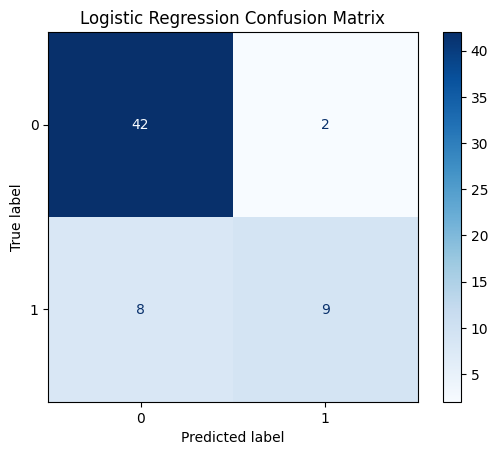

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
display = ConfusionMatrixDisplay(cm_lr, display_labels=lr_model.classes_)
display.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

AUC Score:  0.9171


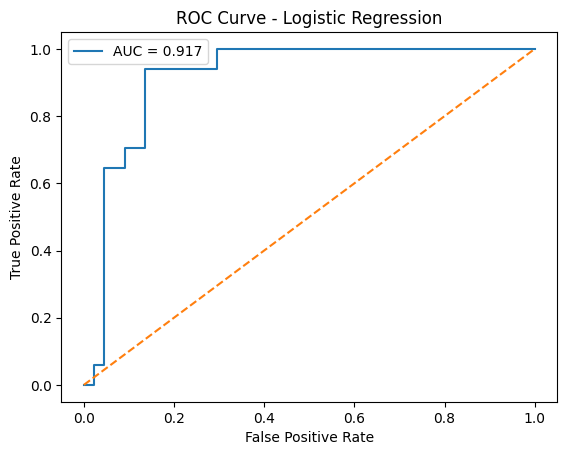

In [ ]:
y_probs_lr = lr_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs_lr)

auc_score = roc_auc_score(y_test, y_probs_lr)
print(f"AUC Score: {auc_score: .4f}")
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Comment:\
Dummy classifier shows that accuracy is not enough since this is a heavily imbalanced data set (Class 0 has 218 counts in comparison to class 1 having 83 counts only), so the model can achieve high accuracy by simply only predicting the majority class while failing to predict the minority class completely. It is more ideal to use other metrics like recall, precision, f-1 scores or ROC-AUC.




---



# Decision Tree and feature importance

In [ ]:
dt_cls = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_cls.fit(X_train, y_train)
dt_cls_pred = dt_cls.predict(X_test)

print(classification_report(y_test, dt_cls_pred))

dt_acc = accuracy_score(y_test, dt_cls_pred)
print(f'Accuracy: {dt_acc: .4f}')

dt_fscore = f1_score(y_test, dt_cls_pred)
print(f'F1 score: {dt_fscore}')

dt_recall = recall_score(y_test, dt_cls_pred)

              precision    recall  f1-score   support

           0       0.80      0.98      0.88        44
           1       0.86      0.35      0.50        17

    accuracy                           0.80        61
   macro avg       0.83      0.67      0.69        61
weighted avg       0.81      0.80      0.77        61

Accuracy:  0.8033
F1 score: 0.5


In [ ]:
imp = pd.Series(dt_cls.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Feature Importances:\n", imp)

Feature Importances:
 num_major_vessels    0.370436
max_heart_rate       0.179097
oldpeak              0.125417
slope_1              0.115845
exercise_angina      0.077161
age                  0.068895
resting_bp           0.038731
chest_pain_type_1    0.024419
cholesterol          0.000000
sex                  0.000000
fasting_bs           0.000000
chest_pain_type_2    0.000000
chest_pain_type_3    0.000000
chest_pain_type_4    0.000000
chest_pain_type_0    0.000000
resting_ecg_0        0.000000
resting_ecg_1        0.000000
resting_ecg_2        0.000000
slope_2              0.000000
slope_3              0.000000
thal_fixed           0.000000
thal_normal          0.000000
thal_reversible      0.000000
dtype: float64


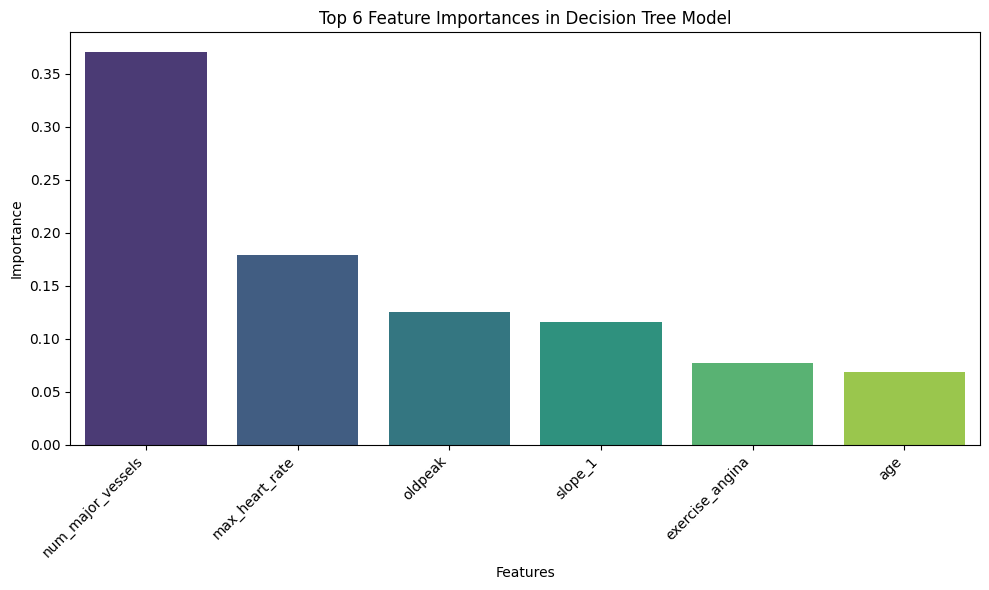

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=imp.head(6).index, y=imp.head(6).values, hue=imp.head(6).index, palette='viridis', legend=False)
plt.title('Top 6 Feature Importances in Decision Tree Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



---



K-nearest Neighbor

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_fscore = f1_score(y_test, y_pred_knn)

MLP

In [ ]:
MLP = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42)
MLP.fit(X_train_scaled, y_train)
y_pred_MLP = MLP.predict(X_test_scaled)

MLP_acc = accuracy_score(y_test, y_pred_MLP)
MLP_recall = recall_score(y_test, y_pred_MLP)
MLP_fscore = f1_score(y_test, y_pred_MLP)

Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Random Forest\nAccuracy: {rf_acc:.4f} | Recall: {rf_recall:.4f} | F1: {rf_f1:.4f}")

Random Forest
Accuracy: 0.8361 | Recall: 0.5294 | F1: 0.6429


Comparison Table

In [ ]:
results = []

results.append(['Dummy', dummy_acc, dummy_recall, dummy_fscore])
results.append(['KNN', knn_acc, knn_recall, knn_fscore])
results.append(['Logistic Regression', lr_acc, lr_recall, lr_fscore])
results.append(['Decision Tree', dt_acc, dt_recall, dt_fscore])
results.append(['MLP', MLP_acc, MLP_recall, MLP_fscore])
results.append(['Random Forest', rf_acc, rf_recall, rf_f1])

comparison_table = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Recall', 'F1 Score'])
comparison_table

,Model,Accuracy,Recall,F1 Score
0,Dummy,0.721311,0.000000,0.000000
1,KNN,0.836066,0.529412,0.642857
2,Logistic Regression,0.836066,0.529412,0.642857
3,Decision Tree,0.803279,0.352941,0.500000
4,MLP,0.852459,0.588235,0.689655
5,Random Forest,0.836066,0.529412,0.642857


Comment:\
MLP model performed best with an F-1 Score of 0.689655. Scaling doesn't matter for tree-based models like RandomForest and Decision Trees because it splits data using thresholds on individual features, with them being scale-invariant. Other models will compare distances or magnitudes of features together, meaning that unscaled features can distort how the weight of some features over others.